### 阶跃函数的图形

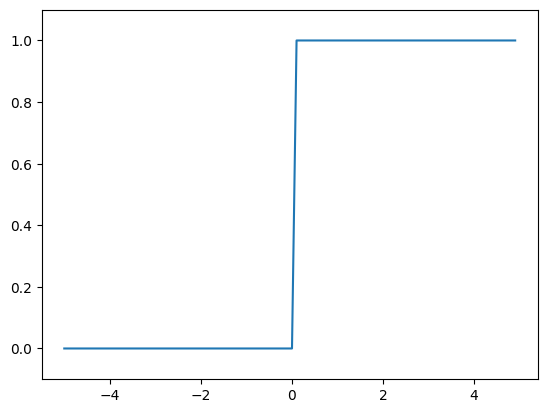

In [3]:
import numpy as np
import matplotlib.pylab as plt

def step_function(x):
    return np.array(x > 0, dtype = int)

x = np.arange(-5.0, 5.0,0.1)
y = step_function(x)
plt.plot(x, y)
plt.ylim(-0.1, 1.1)
plt.show()

### sigmoid 函数的实现

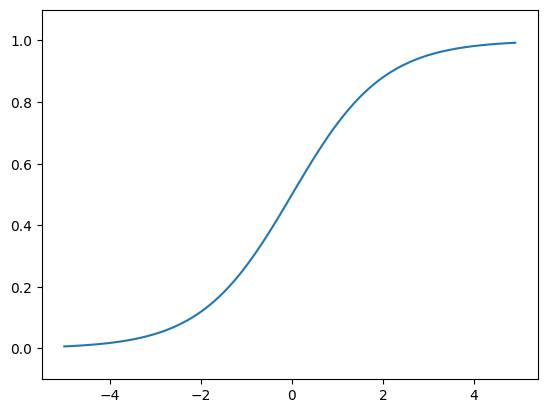

In [4]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.arange(-5.0, 5.0, 0.1)
y = sigmoid(x)
plt.plot(x, y)
plt.ylim(-0.1, 1.1) # 指定 y 轴的范围
plt.show()

相对于阶跃函数只能返回 0 或 1，sigmoid 函数可以返回 0.731 . . .、0.880 . . . 等实数。也就是说，感知机中神经元之间流动的是 0 或 1 的二元信号，而神经网络中流动的是连续的实数值信号。
阶跃函数和 sigmoid 函数两者均为**非线性函数**，神经网络的激活函数必须使用非线性函数，线性函数的问题在于，不管如何加深层数，总是存在与之等效的“无隐藏层的神经网络”，使用线性函数时，无法发挥多层网络带来的优势。因此，为了发挥叠加层所带来的优势，激活函数必须使用非线性函数。

### ReLU(Rectified Linear Unit)函数
ReLU 函数在输入大于 0 时，直接输出该值；在输入小于等于 0 时，输出 0

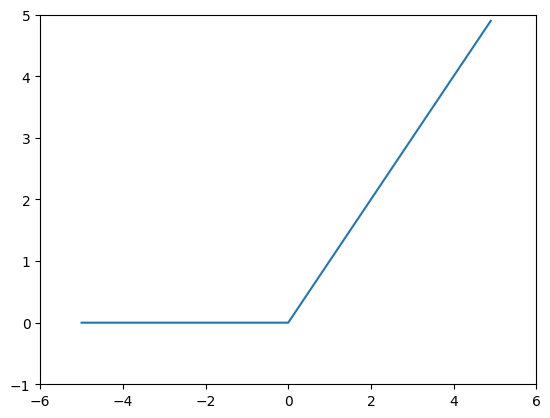

In [6]:
def relu(x):
    return np.maximum(0, x)

x = np.arange(-5.0, 5.0, 0.1)
y = relu(x)
plt.plot(x, y)
plt.ylim(-1, 5) # 指定 y 轴的范围
plt.xlim(-6, 6)
plt.show()

## 多维数组

In [8]:
# NumPy 矩阵实现神经网络
X = np.array([1, 2])
print(f'X的形状为: ', X.shape)
W = np.array([[1, 3, 5],[2, 4, 6]])
print(W, W.shape)
Y = np.dot(X, W)
print(Y) 

X的形状为:  (2,)
[[1 3 5]
 [2 4 6]] (2, 3)
[ 5 11 17]


**神经网络的运算可以作为矩阵运算打包进行。因为神经网络各层的运算是通过矩阵的乘法运算打包进行的（从宏观视角来考虑）**

In [ ]:
# 实现3层神经网络的从输入到输出前向处理
X = np.array([1.0, 0.5])    # 输入X是包含两个元素的一维数组
W1 = np.array([[0.1, 0.3, 0.5], [0.2, 0.4, 0.6]])    # 第一层的权重
B1 = np.array([0.1, 0.2, 0.3])

print(W1.shape)
print(X.shape)
print(B1.shape)

A1 = np.dot(X, W1) + B1
print(A1)    # 第一个隐藏层的加权和
print(A1.shape)

(2, 3)
(2,)
(3,)
[0.3 0.7 1.1]
(3,)


In [12]:
Z1 = sigmoid(A1)    # 第一个隐藏层的加权和经过sigmoid激活函数进行转换
print(Z1)

[0.57444252 0.66818777 0.75026011]


In [13]:
W2 = np.array([[0.1, 0.4], [0.2, 0.5], [0.3, 0.6]])
B2 = np.array([0.1, 0.2])

print(W2.shape)
print(B2.shape)

A2 = np.dot(Z1, W2) + B2
Z2 = sigmoid(A2)
print(A2)
print(Z2)

(3, 2)
(2,)
[0.51615984 1.21402696]
[0.62624937 0.7710107 ]


In [15]:
def identity_function(x):
    return x
W3 = np.array([[0.1, 0.3], [0.2, 0.4]])
B3 = np.array([0.1, 0.2])
A3 = np.dot(Z2, W3) + B3
Y = identity_function(A3) # 或者 Y = A3

print(Y)

[0.31682708 0.69627909]


In [ ]:
# 按照神经网络书写惯例进行书写
def init_network():
    '''
    进行权重和偏置的初始化, 并保存在字典变量network中
    '''
    network = {}
    network['W1'] = np.array([[0.1, 0.3, 0.5], [0.2, 0.4, 0.6]])
    network['b1'] = np.array([0.1, 0.2, 0.3])
    network['W2'] = np.array([[0.1, 0.4], [0.2, 0.5], [0.3, 0.6]])
    network['b2'] = np.array([0.1, 0.2])
    network['W3'] = np.array([[0.1, 0.3], [0.2, 0.4]])
    network['b3'] = np.array([0.1, 0.2])
    return network
def forward(network, x):
    '''
    封装由输入信号转化为输出信号的处理过程
    '''
    W1, W2, W3 = network['W1'], network['W2'], network['W3']
    b1, b2, b3 = network['b1'], network['b2'], network['b3']

    a1 = np.dot(x, W1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, W2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, W3) + b3
    y = identity_function(a3)
    return y
network = init_network()
x = np.array([1.0, 0.5])
y = forward(network, x)
print(network)
print(y) # [ 0.31682708 0.69627909]

{'W1': array([[0.1, 0.3, 0.5],
       [0.2, 0.4, 0.6]]), 'b1': array([0.1, 0.2, 0.3]), 'W2': array([[0.1, 0.4],
       [0.2, 0.5],
       [0.3, 0.6]]), 'b2': array([0.1, 0.2]), 'W3': array([[0.1, 0.3],
       [0.2, 0.4]]), 'b3': array([0.1, 0.2])}
[0.31682708 0.69627909]


### 分类问题中的 softmax 函数实现
可以把 softmax 函数的输出解释为“概率”，也就是说，通过使用 softmax 函数，我们可以用概率的（统计的）方法处理问题。

In [17]:
a = np.array([0.3, 2.9, 4.0])
exp_a = np.exp(a)

sum_exp_a = np.sum(exp_a)
y = exp_a / sum_exp_a
print(y)

[0.01821127 0.24519181 0.73659691]


In [ ]:
def softmax_1(a):
    exp_a = np.exp(a)
    sum_exp_a = np.sum(exp_a)
    y = exp_a / sum_exp_a
    return y

def softmax(a):
    c = np.max(a)
    # 通过给输入值减去输入信号中的最大值(结果不变，证明可看书3.5.2)，来防止数值溢出
    exp_a = np.exp(a - c) 
    sum_exp_a = np.sum(exp_a)
    y = exp_a / sum_exp_a
    return y